# Project 01 (basic) — head tracking: the mathematics behind presence

> **Module 17 — Core XR** - Format: **Jupyter notebook**
>
> **Why this format?** You only understand rotations if you **try them out**: rotate an axis, see
> that a degree of freedom disappears, watch a drift curve run away. Numbers and plots right next
> to the derivation - that is a notebook.
>
> **Without a VR headset?** Yes - and that is not a makeshift. The intellectual core of XR is
> **mathematics and timing behaviour**. In an engine both disappear behind ready-made functions;
> here you recompute it yourself.

## Goal
You rebuild the mathematics that decides whether a headset produces **presence** or nausea - the
**orientation of the head**:

1. **rotations do not commute** - the source of countless XR bugs,
2. **gimbal lock** - how Euler angles lose a degree of freedom,
3. **quaternions** - why XR uses them, including the $q \equiv -q$ trap,
4. **SLERP vs. LERP** - rotating uniformly,
5. **IMU sensor fusion** - why a gyroscope drifts away and a two-liner repairs it.

## Prior knowledge
Module 17 script, **section 2** (tracking, rotations, sensor fusion). Linear algebra
(matrix × vector), trigonometry. `scipy.spatial.transform` is introduced here.

## What should work at the end
Five recomputed findings - among them that at pitch = 90° the combinations (yaw, roll) =
(0°,0°), (40°,40°), (90°,90°) produce **exactly the same** rotation, and that a complementary
filter (**one line**) is better than either sensor alone.

> **This is the solution notebook.** All `# TODO` places are filled in, and the reference answers
> to the mini exercises are at the very end.


In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R, Slerp

np.set_printoptions(suppress=True, precision=4)
print("Rotations without a VR headset: scipy.spatial.transform")

# Small helpers that we need often
def angle_between(r1, r2):
    # The angle (in degrees) between two rotations:
    # how far do you have to rotate to get from r1 to r2?
    return np.degrees((r1.inv() * r2).magnitude())

print("Check:", round(angle_between(R.from_euler('z', 0, degrees=True),
                                    R.from_euler('z', 90, degrees=True)), 3), "degrees")


Rotations without a VR headset: scipy.spatial.transform
Check: 90.0 degrees


## 1 - Rotations do not commute

The first surprise: with numbers $3\cdot5 = 5\cdot3$. With rotations that does **not** hold:
$$R_A R_B \neq R_B R_A$$

This is not a subtlety - it is the root of almost every coordinate system bug in XR ("why does my
controller tip sideways when I rotate it?").

**Your task:** rotate the point $\hat z = [0,0,1]$ once *first about X, then about Y* and once
*first about Y, then about X* - 90° each. In `scipy`, "first A, then B" is the product `B * A`
(what acts first stands on the right).


In [2]:
A = R.from_euler('x', 90, degrees=True)   # 90 degrees about the X axis
B = R.from_euler('y', 90, degrees=True)   # 90 degrees about the Y axis
v = np.array([0, 0, 1.0])                 # the point we rotate

a_then_b = (B * A).apply(v)               # what acts FIRST stands on the right
b_then_a = (A * B).apply(v)

print("first A then B:", a_then_b)
print("first B then A:", b_then_a)
print("equal?", np.allclose(a_then_b, b_then_a))
print("\n-> The same two rotations, a different order, DIFFERENT points.")
print("   That is why 'Euler angles' without stating the order (ZYX? XYZ?) is meaningless.")


first A then B: [ 0. -1.  0.]
first B then A: [ 1. -0.  0.]
equal? False

-> The same two rotations, a different order, DIFFERENT points.
   That is why 'Euler angles' without stating the order (ZYX? XYZ?) is meaningless.


## 2 - Gimbal lock: a degree of freedom disappears

Now the classic killer of Euler angles. Convention **ZYX** (yaw → pitch → roll).

**The claim:** if the **pitch is at 90°** (looking straight up), the yaw and the roll axis
coincide. Only the **difference** $(\text{yaw}-\text{roll})$ survives - three degrees of freedom
become **two**.

**Your task:** check that. Compare several $(\text{yaw},\text{roll})$ pairs with the **same
difference** at pitch = 90° against the reference $(0°, 90°, 0°)$.

> **Careful, a widespread misconception:** "Then (yaw=0, roll=40) and (yaw=40, roll=0) are equal."
> **No** - their differences differ by 80°, they lie 80° apart. It is the **difference** that
> survives, not the individual value. That is exactly what you are about to recompute.


In [3]:
warnings.filterwarnings("ignore")   # scipy is about to warn about gimbal lock itself

reference = R.from_euler('ZYX', [0, 90, 0], degrees=True)

print("Pitch = 90 degrees, pairs with the SAME difference (yaw - roll = 0):")
for yaw, roll in [(0, 0), (40, 40), (90, 90), (-30, -30)]:
    r = R.from_euler('ZYX', [yaw, 90, roll], degrees=True)
    distance = angle_between(reference, r)
    print(f"  yaw={yaw:4d}  roll={roll:4d}  ->  quat {r.as_quat()}  distance {distance:.6f} deg")

print("\n-> A distance of exactly 0: these are not 'similar' but IDENTICAL rotations.")
print("   The user can no longer control yaw and roll independently: 3 DoF -> 2 DoF.")


Pitch = 90 degrees, pairs with the SAME difference (yaw - roll = 0):
  yaw=   0  roll=   0  ->  quat [0.     0.7071 0.     0.7071]  distance 0.000000 deg
  yaw=  40  roll=  40  ->  quat [0.     0.7071 0.     0.7071]  distance 0.000000 deg
  yaw=  90  roll=  90  ->  quat [0.     0.7071 0.     0.7071]  distance 0.000000 deg
  yaw= -30  roll= -30  ->  quat [-0.      0.7071 -0.      0.7071]  distance 0.000000 deg

-> A distance of exactly 0: these are not 'similar' but IDENTICAL rotations.
   The user can no longer control yaw and roll independently: 3 DoF -> 2 DoF.


In [4]:
# Counter-check 1: a different difference => a different rotation (the remaining DoF)
print("Only the DIFFERENCE counts:")
for diff in (0, 20, 40, 80):
    r = R.from_euler('ZYX', [diff, 90, 0], degrees=True)
    print(f"  yaw-roll = {diff:3d}  ->  distance to the reference {angle_between(reference, r):6.2f} deg")

# Counter-check 2: the famous misconception
r1 = R.from_euler('ZYX', [0, 90, 40], degrees=True)    # difference -40
r2 = R.from_euler('ZYX', [40, 90, 0], degrees=True)    # difference +40
print(f"\n(yaw=0,roll=40) vs (yaw=40,roll=0): {angle_between(r1, r2):.2f} deg "
      f"-> NOT identical (differences -40 vs +40)")

# Counter-check 3: far away from the lock everything is normal
identity = R.from_euler('ZYX', [0, 0, 0], degrees=True)
r_ok = R.from_euler('ZYX', [40, 0, 40], degrees=True)
print(f"\nAt pitch=0: yaw=40,roll=40 is {angle_between(identity, r_ok):.2f} deg from the "
      f"identity -> no lock, everything normal.")

# And this is what the symptom looks like in practice:
back = R.from_euler('ZYX', [0, 90, 40], degrees=True).as_euler('ZYX', degrees=True)
print(f"\nConverting (yaw=0, pitch=90, roll=40) back gives: {back}")
print("-> scipy folds everything into the yaw and sets roll to 0. It CANNOT do otherwise:")
print("   the information about how the 40 degrees were split between yaw/roll no longer exists.")


Only the DIFFERENCE counts:
  yaw-roll =   0  ->  distance to the reference   0.00 deg
  yaw-roll =  20  ->  distance to the reference  20.00 deg
  yaw-roll =  40  ->  distance to the reference  40.00 deg
  yaw-roll =  80  ->  distance to the reference  80.00 deg

(yaw=0,roll=40) vs (yaw=40,roll=0): 80.00 deg -> NOT identical (differences -40 vs +40)

At pitch=0: yaw=40,roll=40 is 55.98 deg from the identity -> no lock, everything normal.

Converting (yaw=0, pitch=90, roll=40) back gives: [-40.  90.   0.]
-> scipy folds everything into the yaw and sets roll to 0. It CANNOT do otherwise:
   the information about how the 40 degrees were split between yaw/roll no longer exists.


## 3 - Quaternions - and the $q \equiv -q$ trap

A unit quaternion encodes a rotation about the axis $\hat{\mathbf n}$ by the angle $\theta$ as
$$q = \Big(\cos\tfrac{\theta}{2},\ \hat{\mathbf n}\sin\tfrac{\theta}{2}\Big)$$

The $\theta/2$ is not a typo: the rotation acts as $\mathbf v' = q\,\mathbf v\,q^{-1}$, i.e.
**twice** - each half contributes $\theta/2$. From this follows the famous curiosity:
**$q$ and $-q$ describe the same rotation.**

That is not cosmetics but a genuine bug generator (see section 4).

**Your task:** build the quaternion for "90° about the Z axis" **by hand** from the formula and
compare it with `scipy`.

> **Convention:** `scipy` stores quaternions as `[x, y, z, w]` - the scalar part $w$ comes
> **last**. Many textbooks (and Unity) write $(w,x,y,z)$. That too is a popular source of errors.


In [5]:
theta = np.radians(90)
axis = np.array([0, 0, 1.0])             # the Z axis

# q = (cos(theta/2), n*sin(theta/2)), in scipy's order [x, y, z, w]
q_hand = np.array([*(axis * np.sin(theta / 2)), np.cos(theta / 2)])

q_scipy = R.from_euler('z', 90, degrees=True).as_quat()
print("by hand :", q_hand)
print("scipy   :", q_scipy)
print("equal?  ", np.allclose(q_hand, q_scipy))
print(f"\ncos(45 deg) = {np.cos(theta/2):.4f} = {q_hand[3]:.4f} -> the theta/2 is in there.")


by hand : [0.     0.     0.7071 0.7071]
scipy   : [0.     0.     0.7071 0.7071]
equal?   True

cos(45 deg) = 0.7071 = 0.7071 -> the theta/2 is in there.


In [6]:
# The q = -q trap: the same q, negated -> an IDENTICAL rotation
q = R.from_euler('z', 90, degrees=True)
q_neg = R.from_quat(-q.as_quat())

print("q     :", q.as_quat())
print("-q    :", q_neg.as_quat())
print(f"Angle between q and -q: {angle_between(q, q_neg):.6f} degrees")
print("-> Different numbers, exactly the same rotation (the double cover).")
print("\nWhy that matters: whoever compares quaternions numerically ('are the poses equal?')")
print("gets a wrong 'no' here. You have to check |q1 . q2| ~ 1, not q1 == q2:")
d = abs(np.dot(q.as_quat(), q_neg.as_quat()))
print(f"   |dot product| = {d:.4f} -> ~1 = the same rotation")


q     : [0.     0.     0.7071 0.7071]
-q    : [-0.     -0.     -0.7071 -0.7071]
Angle between q and -q: 0.000000 degrees
-> Different numbers, exactly the same rotation (the double cover).

Why that matters: whoever compares quaternions numerically ('are the poses equal?')
gets a wrong 'no' here. You have to check |q1 . q2| ~ 1, not q1 == q2:
   |dot product| = 1.0000 -> ~1 = the same rotation


## 4 - SLERP vs. LERP - rotating uniformly

A headset has to interpolate between two orientations (e.g. to smooth network frames). Two ways:

- **LERP**: average the quaternions component-wise and normalize. Runs the **chord** through the
  sphere.
- **SLERP**: along the **great circle** on the unit sphere - the shortest rotation with **constant
  angular velocity**.

**Your task:** interpolate 0° → 170° about the Y axis with both methods and measure the **step
sizes**. Constant angular velocity means: all steps are equally large.


In [7]:
q0 = R.from_euler('y', 0, degrees=True)
q1 = R.from_euler('y', 170, degrees=True)
ts = np.linspace(0, 1, 6)

# --- SLERP (scipy) ---
slerp = Slerp([0, 1], R.concatenate([q0, q1]))
angles_slerp = np.degrees(slerp(ts).magnitude())

# --- LERP by hand ---
a0, a1 = q0.as_quat(), q1.as_quat()
lerp = np.array([(1 - t) * a0 + t * a1 for t in ts])
lerp = lerp / np.linalg.norm(lerp, axis=1, keepdims=True)     # back onto the unit sphere
angles_lerp = np.degrees(R.from_quat(lerp).magnitude())

print("t     :", np.round(ts, 2))
print("SLERP :", np.round(angles_slerp, 1))
print("LERP  :", np.round(angles_lerp, 1))
print(f"\nStep sizes  SLERP: spread {np.diff(angles_slerp).std():.3f}  <- exactly constant")
print(f"            LERP : spread {np.diff(angles_lerp).std():.3f}  <- uneven")
print("\n-> LERP is too fast in the middle (the chord instead of the arc). For SMALL angles the")
print("   difference is negligible - which is why LERP between dense frames is common anyway.")


t     : [0.  0.2 0.4 0.6 0.8 1. ]
SLERP : [  0.  34.  68. 102. 136. 170.]
LERP  : [  0.   27.4  64.2 105.8 142.6 170. ]

Step sizes  SLERP: spread 0.000  <- exactly constant
            LERP : spread 5.659  <- uneven

-> LERP is too fast in the middle (the chord instead of the arc). For SMALL angles the
   difference is negligible - which is why LERP between dense frames is common anyway.


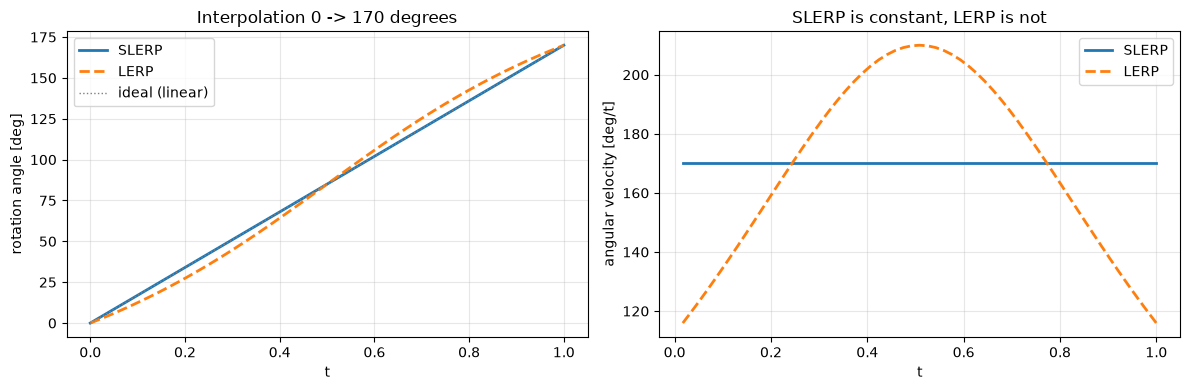

In [8]:
ts_fine = np.linspace(0, 1, 60)
w_s = np.degrees(slerp(ts_fine).magnitude())
l = np.array([(1-t)*a0 + t*a1 for t in ts_fine]); l /= np.linalg.norm(l, axis=1, keepdims=True)
w_l = np.degrees(R.from_quat(l).magnitude())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ts_fine, w_s, lw=2, label="SLERP")
ax1.plot(ts_fine, w_l, lw=2, ls="--", label="LERP")
ax1.plot([0, 1], [0, 170], ":", color="gray", lw=1, label="ideal (linear)")
ax1.set(xlabel="t", ylabel="rotation angle [deg]", title="Interpolation 0 -> 170 degrees")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ts_fine[1:], np.diff(w_s)/np.diff(ts_fine), lw=2, label="SLERP")
ax2.plot(ts_fine[1:], np.diff(w_l)/np.diff(ts_fine), lw=2, ls="--", label="LERP")
ax2.set(xlabel="t", ylabel="angular velocity [deg/t]",
        title="SLERP is constant, LERP is not")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 5 - IMU sensor fusion: why a gyroscope drifts away

Now the practical core of tracking. An IMU has two sensors with **complementary** errors
(script 2.4):

| | Gyroscope | Accelerometer |
|---|---|---|
| measures | angular **velocity** | acceleration + **gravity** |
| short term | **precise, smooth** | **noisy** |
| long term | **drifts away** | **drift-free** (down stays down) |

**Why does the gyro drift?** We need the *angle* but have the *velocity* - so we **integrate**:
$\theta_k=\theta_{k-1}+\omega_k\Delta t$. Every bias, however small, accumulates **without
bound** in the process.

We simulate 60 s: a head nodding gently, a gyro with a **0.5 °/s bias**, a noisy accelerometer.


In [9]:
rng = np.random.default_rng(0)
dt = 1 / 100                      # 100 Hz
T = 60                            # seconds
n = int(T / dt)
t = np.arange(n) * dt

# The truth: the head nods gently (+/- 20 degrees, 0.2 Hz)
truth = np.deg2rad(20) * np.sin(2 * np.pi * 0.2 * t)

# Gyro: measures the derivative - precise, but with a BIAS (0.5 deg/s) and some noise
gyro = np.gradient(truth, dt) + np.deg2rad(0.5) + rng.normal(0, 0.01, n)

# Accelerometer: measures the angle absolutely via gravity - drift-free, but noisy
accel = truth + rng.normal(0, np.deg2rad(3), n)

print(f"{n} measurements over {T}s at {int(1/dt)} Hz")
print(f"Gyro bias: 0.5 deg/s  ->  after {T}s that would be {0.5*T:.0f} degrees of error "
      f"if you only integrate it.")


6000 measurements over 60s at 100 Hz
Gyro bias: 0.5 deg/s  ->  after 60s that would be 30 degrees of error if you only integrate it.


**Your task:** implement the three estimators.

1. **Gyro only** - integrate: $\theta_k=\theta_{k-1}+\omega_k\,\Delta t$
2. **Accel only** - the measurement itself is already the angle.
3. **The complementary filter** - the one line that saves everything:
$$\theta_k = \alpha\big(\theta_{k-1}+\omega_k\Delta t\big) + (1-\alpha)\,\theta_{\text{accel},k}$$
In the short term it follows the smooth gyro, in the long term the accel pulls it back to the
truth.


In [10]:
alpha = 0.98
gyro_only = np.zeros(n)
complementary = np.zeros(n)

for k in range(1, n):
    gyro_only[k] = gyro_only[k-1] + gyro[k] * dt                          # pure integration
    complementary[k] = (alpha * (complementary[k-1] + gyro[k] * dt)       # high pass on the gyro
                        + (1 - alpha) * accel[k])                         # low pass on the accel

def rmse_deg(estimate):
    return np.rad2deg(np.sqrt(np.mean((estimate - truth) ** 2)))

print(f"{'Estimator':24s} {'RMSE [deg]':>12s} {'final error [deg]':>18s}")
for name, s in [("gyro only (integrated)", gyro_only), ("accel only", accel),
                ("complementary filter", complementary)]:
    print(f"{name:24s} {rmse_deg(s):12.2f} {np.rad2deg(s[-1]-truth[-1]):18.2f}")
print("\n-> The filter is BETTER THAN BOTH individual sensors - two poor sources")
print("   become one good one, because their errors are complementary.")


Estimator                  RMSE [deg]  final error [deg]
gyro only (integrated)          16.98              29.95
accel only                       3.01               1.22
complementary filter             0.42               0.32

-> The filter is BETTER THAN BOTH individual sensors - two poor sources
   become one good one, because their errors are complementary.


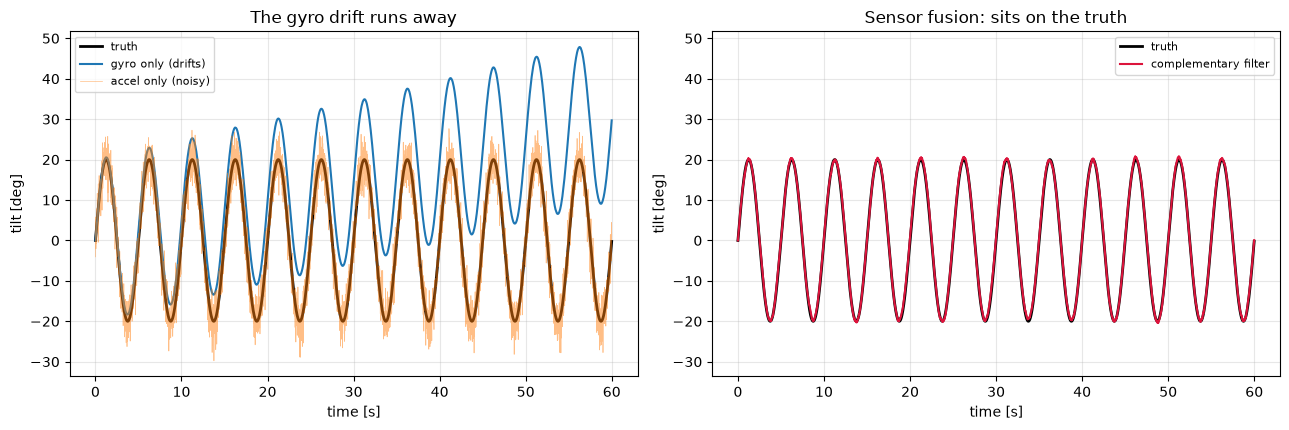

The left plot is the reason why a 3 DoF headset without fusion has the world standing
crooked after a minute. The right one is the reason why it works anyway.


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
ax1.plot(t, np.rad2deg(truth), "k", lw=2, label="truth")
ax1.plot(t, np.rad2deg(gyro_only), lw=1.5, label="gyro only (drifts)")
ax1.plot(t, np.rad2deg(accel), lw=0.5, alpha=0.5, label="accel only (noisy)")
ax1.set(xlabel="time [s]", ylabel="tilt [deg]", title="The gyro drift runs away")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2.plot(t, np.rad2deg(truth), "k", lw=2, label="truth")
ax2.plot(t, np.rad2deg(complementary), lw=1.5, color="crimson", label="complementary filter")
ax2.set(xlabel="time [s]", ylabel="tilt [deg]",
        title="Sensor fusion: sits on the truth", ylim=ax1.get_ylim())
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("The left plot is the reason why a 3 DoF headset without fusion has the world standing")
print("crooked after a minute. The right one is the reason why it works anyway.")


## 6 - Conclusion

**What you have recomputed:**

1. **Rotations do not commute** - the same two 90° rotations give either $[0,-1,0]$ or $[1,0,0]$
   depending on the order. "Euler angles" without stating the order (ZYX? XYZ?) is meaningless.
2. **Gimbal lock**: at pitch = 90°, (yaw, roll) = (0°,0°), (40°,40°), (90°,90°) are **exactly the
   same** rotation - a distance of **0.000000°**. Only the **difference** survives:
   **3 DoF → 2 DoF**. The back-conversion *cannot* reconstruct the lost information.
3. **Quaternions**: $q=(\cos\frac\theta2, \hat{\mathbf n}\sin\frac\theta2)$ by hand = scipy.
   And **$q \equiv -q$** - whoever compares poses with `==` has a bug; the correct way is
   $|q_1\cdot q_2|\approx1$.
4. **SLERP** has exactly constant angular steps (spread **0.000**), **LERP** does not (**5.659**).
5. **Sensor fusion**: gyro only RMSE **16.98°** (final error **29.95°** - the world tips away),
   accel only **3.01°**, **complementary filter 0.42°** - better than either individual sensor.

> **The connection to the script:** this is not a mathematical finger exercise. According to
> Slater (1.2), **presence** arises from **sensorimotor contingency** - the world has to react to
> the head movement *as it would in reality*. That is exactly what the five building blocks above
> deliver. If your gyro drifts (point 5), the world tips; if a gimbal lock catches you (point 2),
> the view jerks; if you interpolate wrongly (point 4), it wobbles. **In every case the place
> illusion collapses - and the user gets sick.** Hence quaternions, hence sensor fusion.

### Mini exercises
1. **Vary α** (0.5 / 0.9 / 0.98 / 0.999): at which value is the filter best? What happens at
   α = 1.0 - and why is that exactly case 1?
2. **Multiply the bias by ten** (5 °/s): how much does the gyro error grow, how much the filter's?
3. **The long way round:** interpolate with SLERP from 0° to 350°. Does scipy take the short (10°)
   or the long way? What does that have to do with $q \equiv -q$? *(Hint: negate `q1` and look
   again.)*
4. **No lock with quaternions:** repeat section 2, but compare two orientations near pitch = 90°
   directly as quaternions. Does a degree of freedom disappear there?
5. **Magnetometer:** the accel corrects pitch and roll - why can it *not* correct **yaw** in
   principle? (Hint: what does gravity do under a rotation about the vertical axis?)

---

### Reference answers to the mini exercises

*(All numbers measured with this simulation, `seed = 0`; run the experiments yourself - the point
is the pattern, not the fourth decimal.)*

**1. Varying α.** The result is a clear U shape with an optimum in between:

| α | RMSE | final error |
|---|---|---|
| 0.5 | 1.76° | 1.80° |
| 0.9 | 0.72° | 0.12° |
| **0.98** | **0.42°** | 0.32° |
| 0.999 | 4.33° | 5.29° |
| **1.0** | **16.98°** | **29.95°** |

α weights how much the filter trusts the gyro. **Small α** means it hangs almost entirely on the
accel and inherits its noise (0.5 → 1.76°, close to the accel's 3.01°). **Large α** means the
accel barely gets to correct any more and the gyro drift creeps back in (0.999 → 4.33°). And
**α = 1.0 is exactly case 1**: the term $(1-\alpha)\theta_{\text{accel}}$ vanishes completely,
the formula degenerates into the pure integration $\theta_k=\theta_{k-1}+\omega_k\Delta t$ - and
indeed the measurement is *bit-identical* to gyro only (16.98° / 29.95°). The filter has no magic
of its own; it lives entirely off the accel being allowed to pull it back a tiny bit each step.

**2. The bias multiplied by ten (5 °/s).** The gyro error grows **linearly** with the bias:
RMSE 16.98° → **172.84°**, final error 29.95° → **299.90°** (= 5 °/s × 60 s, exactly as predicted).
After a minute the world is spinning almost a full turn too far. The filter, by contrast, grows
only from 0.42° → **2.49°** - a factor of 6 rather than 10, and above all it stays **bounded**.
That is the decisive structural difference: the integration error is **unbounded** (it grows with
the runtime), the filter error settles at a **stationary level** that depends on the bias but not
on the runtime. Doubling the session length changes nothing for the filter and doubles the pure
gyro's error.

**3. SLERP from 0° to 350°.** scipy takes the **short** way: the interpolated angles are
0, 2, 4, 6, 8, **10°** — not 0 … 350°. The reason is the double cover. A rotation of 350° about Y
is the same rotation as −10° about Y, and the corresponding quaternion has
$q_0\cdot q_1 = -0.9962 < 0$, i.e. the two lie in *opposite* hemispheres of the quaternion sphere.
scipy checks the sign and internally flips $q_1 \to -q_1$, so the great circle runs the short 10°
arc. If you negate `q1` yourself, you get **exactly the same** result — which is the proof that the
flip has already happened internally. A hand-rolled SLERP **without** this sign check would happily
run 350° the other way round: the classic "my object spins all the way round for a 10° turn" bug.

**4. Quaternions near pitch = 90°.** No degree of freedom disappears — and it never did. A 5° yaw
change produces a rotation distance of exactly 5.0000° at pitch = 0, at pitch = 89.9° **and** at
pitch = 90°. The quaternion representation is regular everywhere.
What has to be said carefully: at pitch = 90° the *rotations* (yaw=0,roll=0) and (yaw=40,roll=40)
really are identical, and the quaternion reports that correctly (distance 0). **Gimbal lock is a
property of the Euler parametrization, not of the rotation.** What is lost is only the ability to
recover the individual values yaw and roll from the rotation — the rotation itself was never
ambiguous. This is exactly why XR stores poses as quaternions and converts to Euler angles at most
for display.

**5. Why the accel cannot correct yaw.** The accelerometer's whole absolute reference is the
gravity vector: it knows "where is down". A **yaw** rotation is a rotation *about* precisely that
vertical axis — and it leaves gravity **unchanged**. The sensor reading is bit-identical whether you
face north or south. So the information simply is not in the signal, and no amount of filtering can
extract it. Pitch and roll, by contrast, tilt the gravity vector in the sensor's frame and are
therefore observable. This is why a headset needs a third source for absolute yaw: a
**magnetometer** (a compass, susceptible to interference from metal and electronics) or, in
practice, the cameras (SLAM), which fix the yaw against the room itself.
